# MNIST Dataset Exploration for ViT
This notebook demonstrates how to load the MNIST dataset and prepare the image data for a Vision Transformer. 
[cite_start]We will download the data using `MLDatasets.jl` and visualize a sample. [cite: 49]

In [2]:
using MLDatasets
using Images
using LinearAlgebra

# Load the full training set
# This will trigger a download (~55MB) on the first run. [cite: 49]
train_x, train_y = MNIST(split=:train)[:]

println("Dataset loaded!")
println("Number of images: ", size(train_x, 3))
println("Image resolution: ", size(train_x, 1), "x", size(train_x, 2))

Dataset loaded!
Number of images: 60000
Image resolution: 28x28


### Visualizing a Sample
Let's look at the first digit in the dataset to ensure it loaded correctly.

Label: 5


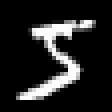

In [3]:
# Extract the first image (Julia uses 1-based indexing)
sample_img = train_x[:, :, 1]
label = train_y[1]

println("Label: ", label)

# Convert the matrix to a grayscale image for display
Gray.(sample_img')

### Patching for Transformers
[cite_start]In your proposal, you mentioned formatting images as sequences. [cite: 49] 
A 28x28 image can be split into patches (e.g., 7x7). 
[cite_start]Each patch is then flattened into a vector to be processed by the Attention mechanism. [cite: 34]